A set of simulations & hypothesis tests for assessing the statistical power of "minP vs CRE of interest" tests in the cohen dataset...

I have not included a lot of explanations because this notebook is extremely similar to the two_thirds_inactive for shendure, which has lots of explanations. Take a look at those if you are having trouble undersanting this notebook...

# Imports & dask cluster creation

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path

%load_ext autoreload
%autoreload 2

2026-02-18 18:50:06.871132: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 18:50:06.875214: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
local=True
if local:
    cluster=LocalCluster()
    #cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=5,#cores per slurm job
        memory="256G",#memory per slurm job
        processes=1,#dask workers per slurm job,
        job_extra_directives=["-p ycga", 
            f"--job-name=simclust_worker",
            f"--time=4:00:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=5)
    #cluster.scale(jobs=20)
    #cluster.scale(jobs=20)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [4]:
#data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")
data_root=Path("/gpfs/gibbs/pi/reilly/tabula_data")
client.dashboard_link

'http://127.0.0.1:8787/status'

# Ground truth creation

In [ ]:
primordial=scm.ortho.load(client,path=data_root,name="cohen_ortho")
primordial.compute_model_qc()

In [ ]:
import pandas as pd
import numpy as np

vals=[]
for key in primordial.by_cell_qc.keys():
    working=primordial.by_cell_qc[key]['dat'].reset_index().drop(columns=["mean(umis_mpra_bc)"])
    working["cell_type"]=key
    vals.append(working)
gt_cell_type=pd.concat(vals)

In [ ]:
#casting away from sparse, since it's not sparse anymore
gt_cell_type["mu"] = gt_cell_type["mu"].astype(float)


In [ ]:
gt_cell_type

In [ ]:
combo_counts=gt_cell_type[gt_cell_type["cre_id"]!="reference"].drop(columns=["mu"]).groupby("cell_type").nunique()
max_tfection=max(combo_counts["cre_id"])
combo_counts

So quite unlike shendure we have total transfection..!

In [ ]:
gt_cell_type=gt_cell_type[gt_cell_type["cre_id"]!="reference"]

In [ ]:
real_means=gt_cell_type.drop(columns=["cre_id","cell_type"])
real_means

In [ ]:
num_cell_types=len(gt_cell_type["cell_type"].unique())
num_cell_types

In [ ]:
synth_cre_names=[f"synthcre_{i}" for i in range(0,len(real_means))]

parts=[]
for i in range(0,num_cell_types):
    working=real_means.sample(frac=1)
    working["cre_id"]=synth_cre_names
    working["cell_type"]=f"ct_{i}"
    parts.append(working)

cartesian=pd.concat(parts).sample(frac=1).reset_index(drop=True)
cartesian

In [ ]:
#make 70% inactive
minP=scm.COHEN_BOUNDS.reference_activity
num_inactive=int(len(cartesian)*0.7)
cartesian.loc[cartesian.index[:num_inactive],"mu"]=minP
cartesian

In [ ]:
#now we pick max_tfection CREs to proceed with, because this is the number of unique cre_id 
#found in the the cell type with the most unique CRE ids (all are the same in cohen)

chosen_cre_id=np.random.choice(cartesian["cre_id"].unique(),max_tfection,replace=False)
sampled_nbs=cartesian[cartesian["cre_id"].isin(chosen_cre_id)]
sampled_nbs

In [ ]:
ref_df=pd.DataFrame({"cell_type":[f"ct_{i}" for i in range(0,num_cell_types)]})
ref_df["mu"]=minP
ref_df["cre_id"]="reference"
ref_df


In [ ]:
final_gt=pd.concat([ref_df,sampled_nbs])
final_gt["cell_type"]=final_gt["cell_type"].replace({"ct_0":"reference"})
final_gt

# Creating artificial libraries

In [ ]:
libraries=[scm.simulate_library(CREs=final_gt["cre_id"],
                 library_model=scm.COHEN_BOUNDS.library_model)
                 for i in range(5)]

# Creating sim


In [ ]:
bound=scm.COHEN_BOUNDS.copy()

In [ ]:
print(bound.cells_per_cell_type.name)
print(bound.cells_per_cell_type.index.name)
s=bound.cells_per_cell_type
s

In [ ]:
s.index=[f"ct_{i}" for i in range(1,num_cell_types)]+["reference"]
s

In [ ]:
bound.cells_per_cell_type=s

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-02-05",
                            client=client,
                            libraries=libraries,
                            library_mapping="corresponding",
                            flatten_overtransfection=True,
                            n_sims=5,
                            experiment_bounds=bound,
                            ground_truth=final_gt)

In [ ]:
sim.gamut()

In [ ]:
sim.save()

# Fit orthos

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-02-05",
                            client=client)

In [ ]:
sim.fit_orthos(serial_orthos=False,direction="by_cell_type")

In [ ]:
sim.save()

# Wald precompute

In [4]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-02-05",
                            client=client)

scMPRAforge: INFO: 'state.parquet' found for 'twothird_pow_sim_2026-02-05', loading.


In [5]:
sim.precompute_wald(cov_method="opg")

In [6]:
sim.save()

In [7]:
sim.precompute_wald(cov_method="sandwich")

In [8]:
sim.save()

# Hypothesis testing

## Add hypotheses

In [9]:
example_data=scm.scMPRA_data.from_parquet(sim.scmpradatp/"0.scmpra")

In [10]:
example_data

In [11]:
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=example_data,
    reference_cre="reference",
)

In [12]:
hs_all_ct.df

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta
0,synthcre_140,ct_1,reference,ct_1,<NA>
1,synthcre_149,ct_1,reference,ct_1,<NA>
2,synthcre_158,ct_1,reference,ct_1,<NA>
3,synthcre_171,ct_1,reference,ct_1,<NA>
4,synthcre_190,ct_1,reference,ct_1,<NA>
...,...,...,...,...,...
447,synthcre_99,reference,reference,reference,<NA>
448,synthcre_356,reference,reference,reference,<NA>
449,synthcre_383,reference,reference,reference,<NA>
450,synthcre_290,reference,reference,reference,<NA>


In [13]:
sim.add_hypothesis_set("hs_all_ct",hs_all_ct)
sim.save()

# Run tests

In [14]:
sim.wald("hs_all_ct")

In [15]:
sim.wald("hs_all_ct",cov_method="opg")

In [16]:
sim.mwu("hs_all_ct")

In [17]:
sim.save()

# Performance metrics

In [5]:
sim=scm.de_novo_simulation(location=data_root,
                            name="twothird_pow_sim_2026-02-05",
                            client=client)

scMPRAforge: INFO: 'state.parquet' found for 'twothird_pow_sim_2026-02-05', loading.


In [6]:
sim._all_classifier_summary("hs_all_ct")

scMPRAforge: INFO: Dropped 8 or 1.8% of tests with NA values for test:mwu, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_sandwich, rep:4.


,replicate,auroc,auprc,test
0,0,0.778546,0.758303,mwu
1,1,0.817518,0.779758,mwu
2,2,0.791658,0.780228,mwu
3,3,0.803060,0.768964,mwu
4,4,0.778275,0.755369,mwu
0,0,0.799945,0.771960,wald_opg
1,1,0.806362,0.776127,wald_opg
2,2,0.786618,0.778515,wald_opg
3,3,0.772822,0.727396,wald_opg
4,4,0.789919,0.767708,wald_opg


scMPRAforge: INFO: Dropped 8 or 1.8% of tests with NA values for test:mwu, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_sandwich, rep:4.


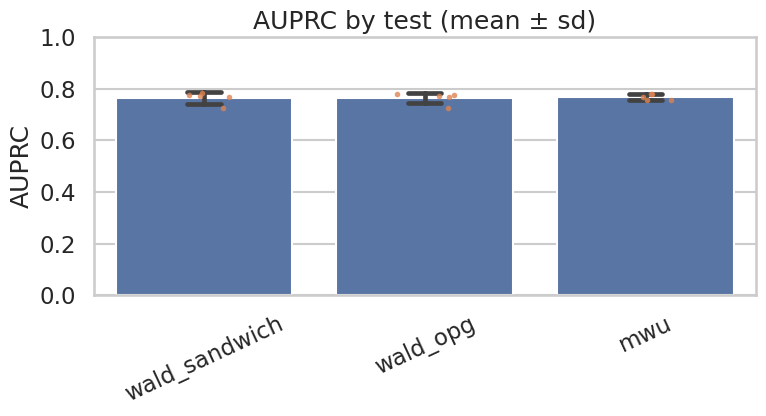

In [7]:
sim.performance_barchart("hs_all_ct","auprc")

scMPRAforge: INFO: Dropped 8 or 1.8% of tests with NA values for test:mwu, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_sandwich, rep:4.


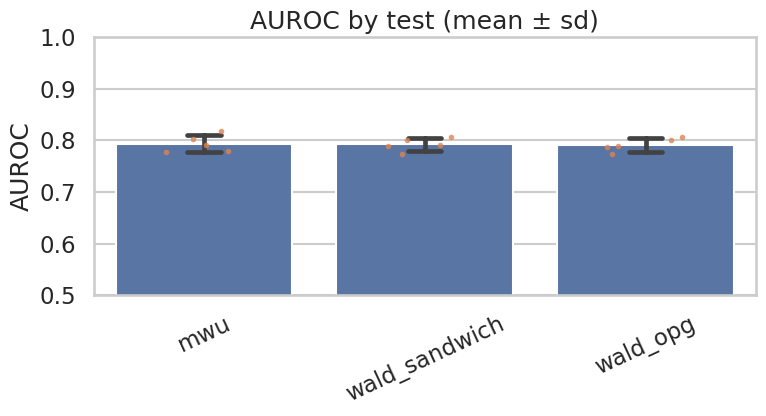

In [8]:
sim.performance_barchart("hs_all_ct","auroc")

scMPRAforge: INFO: Dropped 8 or 1.8% of tests with NA values for test:mwu, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_sandwich, rep:4.


Called positive: 76 / 452 (16.8142%)
Called positive: 89 / 449 (19.8218%)
Called positive: 89 / 449 (19.8218%)


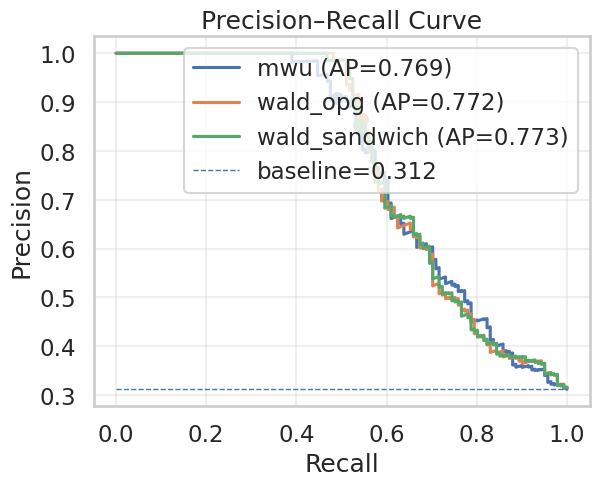

In [10]:
sim.median_performance_curve(hypothesis_set_name="hs_all_ct",performance_type="PRC")

scMPRAforge: INFO: Dropped 8 or 1.8% of tests with NA values for test:mwu, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_opg, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_opg, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_sandwich, rep:0.
scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_sandwich, rep:1.
scMPRAforge: INFO: Dropped 15 or 3.3% of tests with NA values for test:wald_sandwich, rep:4.


Called positive: 97 / 452 (21.4602%)
Called positive: 103 / 437 (23.5698%)
Called positive: 93 / 452 (20.5752%)


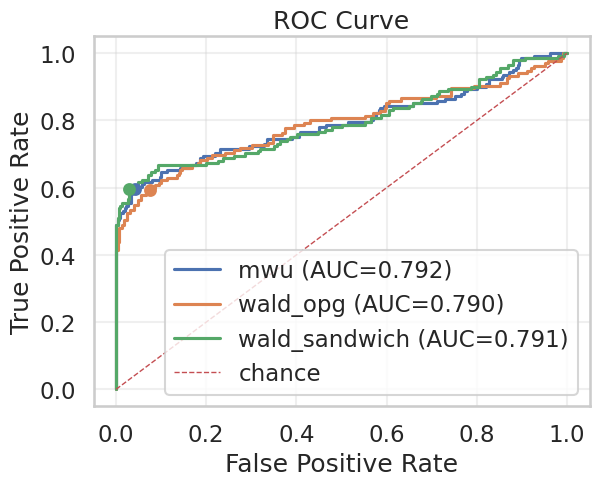

In [11]:
sim.median_performance_curve(hypothesis_set_name="hs_all_ct",performance_type="ROC")

# Shutdown

In [31]:
client.close()
cluster.close()